<a href="https://colab.research.google.com/github/rubenesticesi/cienciasdedatos1/blob/master/PrediccionAutismo_Ajuste.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


#PREDICCION DEL AUTISMO

Con base en el conjunto de datos suministrado  adjuntos,

1 - Escribir el Código Python para todo lo siguiente:

a - Balancear los datos contenidos en el dataset adjunto
b - Los Datos Faltantes de las  Columnas como ethnicity y relation y otros si existen
c - Los Valores Atípicos (Outliers)en la columna age (383 años) y otros si existen
d - Equilibrar la Variable Objetivo (Class/ASD), para evitar  la perdidad de sensibilidad para detectar casos positivos

e - presentar nuevamente el analisis univariado y variado , con el dataset balanceado,realizar el analisis explotario de los datos completos, con todos los graficos que muestren los resultados obtenidos y las conclusiones de cada resultado, su correspondiente codigo python para ello

f - realizar la matriz de correlacion y con su explicacion del significado de los hallazgos, y su correspondiente codigo python
g - realizar la matriz de confusion y con su explicacion del significado de los hallazgos, y su correspondiente codigo python

h- Identificar los posibles sesgos o patrones entro de los datos,
i- Describir y resumir los hallazgos claves obtenidos en el análisis,
j- Mencionar implicaciones o próximos pasos que podían derivarse de los resultados,

2- Generar un informe en PDF, que incluya :

a- Introducción y selección de la variable escogida, explicación y su importancia,
b- Escribir el código python en el informe, con su análisis univariado y análisis bivariado y las visualizaciones realizadas y la interpretación de los resultados,
c- Colocar los gráficos describiendo los hallazgos,
d- Realizar la matriz de correlacion explicándola en detalle
e- Realizar las conclusiones, y recomendaciones para la prevención del autismo

#Análisis Predictivo del Trastorno del Espectro Autista (TEA)

CARGA Y EXPLORACIÓN INICIAL DEL DATASET
Forma del dataset: (704, 21)
Número de variables: 21
Número de observaciones: 704

Tipos de datos por variable:
int64      10
object      9
float64     2
Name: count, dtype: int64

Información detallada del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   A1_Score         704 non-null    int64  
 1   A2_Score         704 non-null    int64  
 2   A3_Score         704 non-null    int64  
 3   A4_Score         704 non-null    int64  
 4   A5_Score         704 non-null    int64  
 5   A6_Score         704 non-null    int64  
 6   A7_Score         704 non-null    int64  
 7   A8_Score         704 non-null    int64  
 8   A9_Score         704 non-null    int64  
 9   A10_Score        704 non-null    int64  
 10  age              702 non-null    float64
 11  gender           704 non-null    obj

FileNotFoundError: [Errno 2] No such file or directory: 'relacion_age_vs_Class/ASD_balanceada.png'

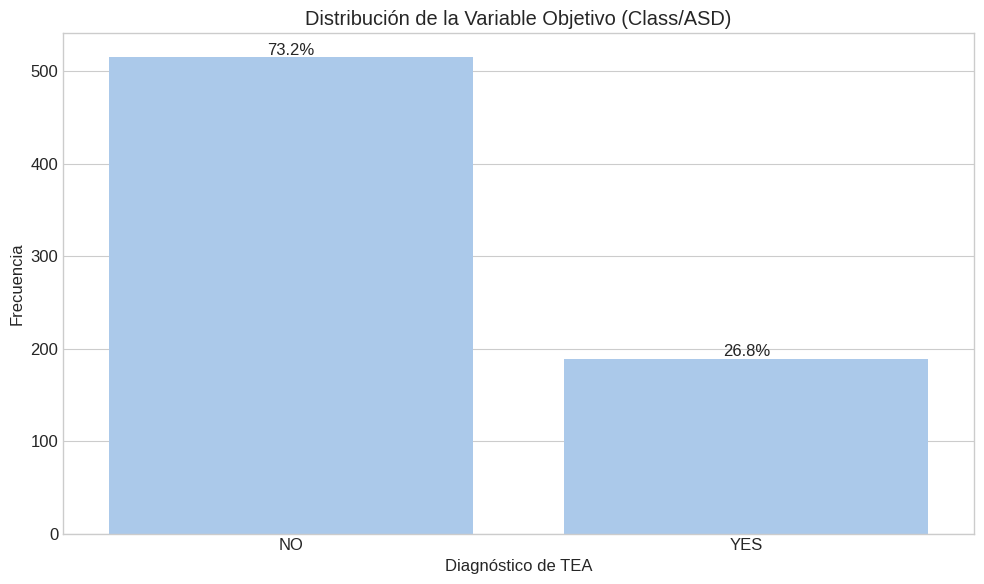

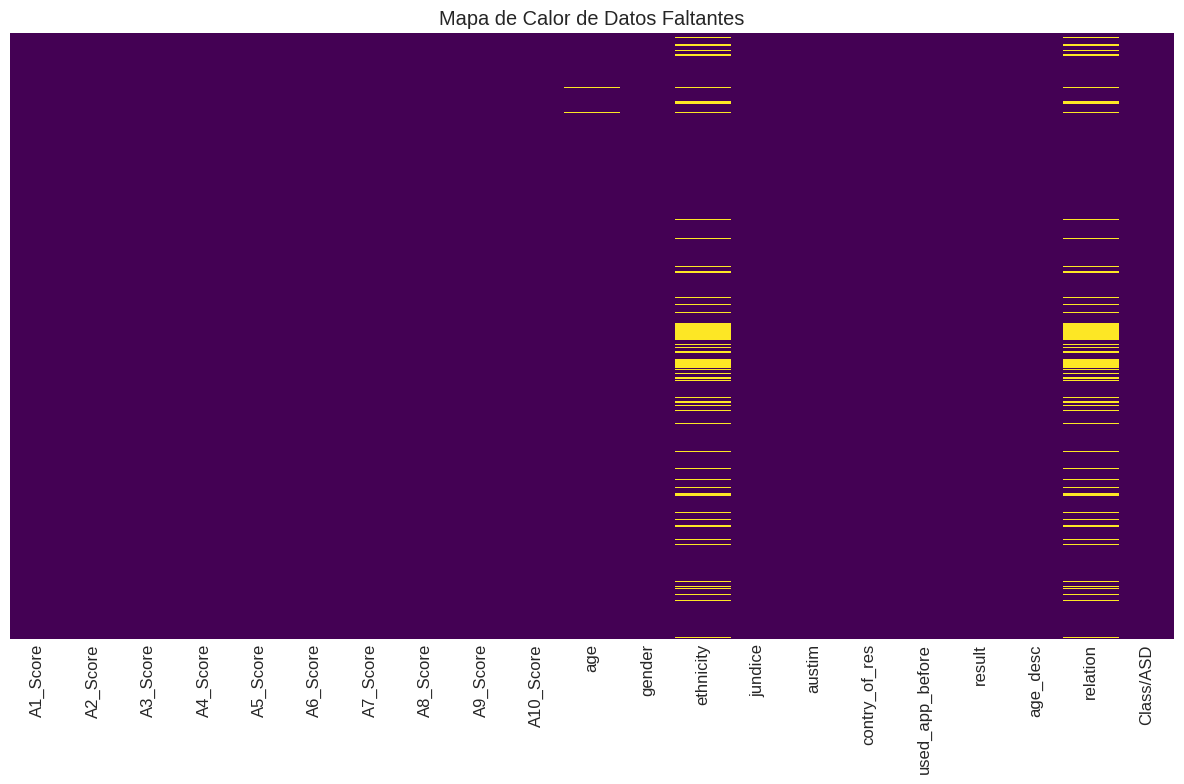

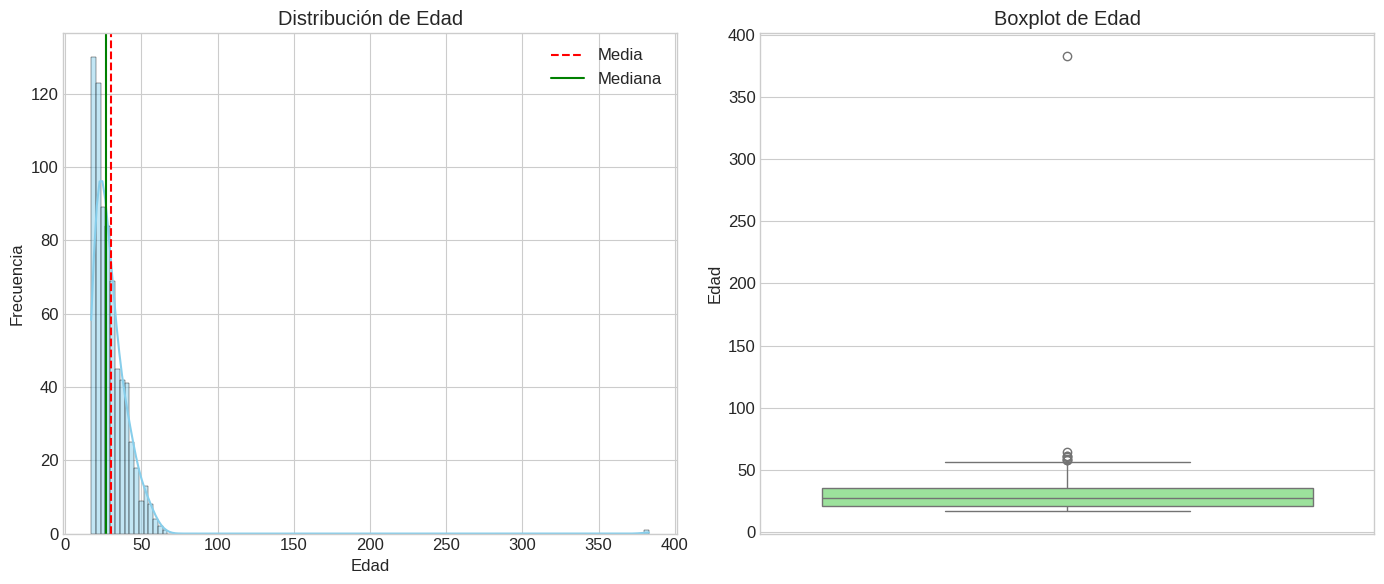

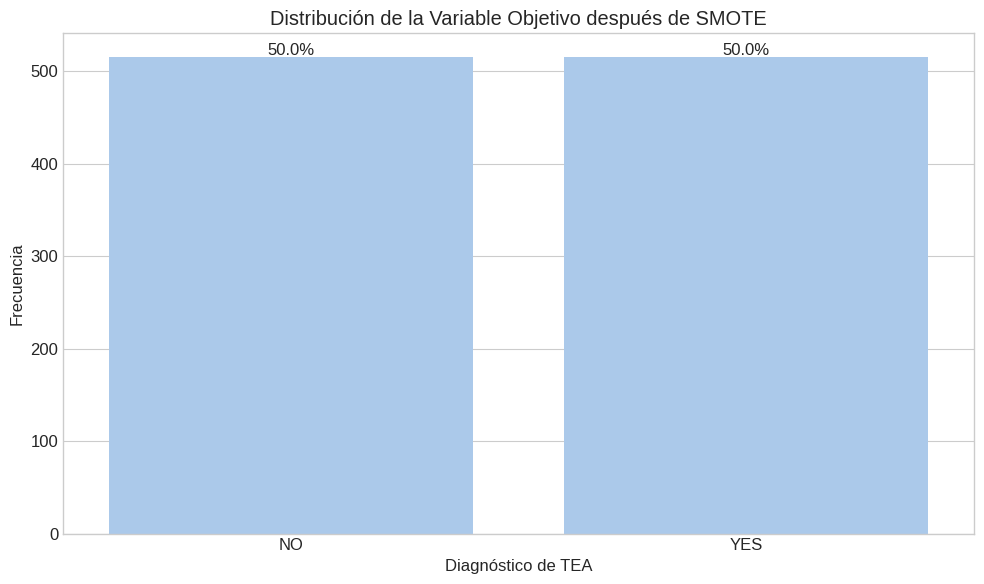

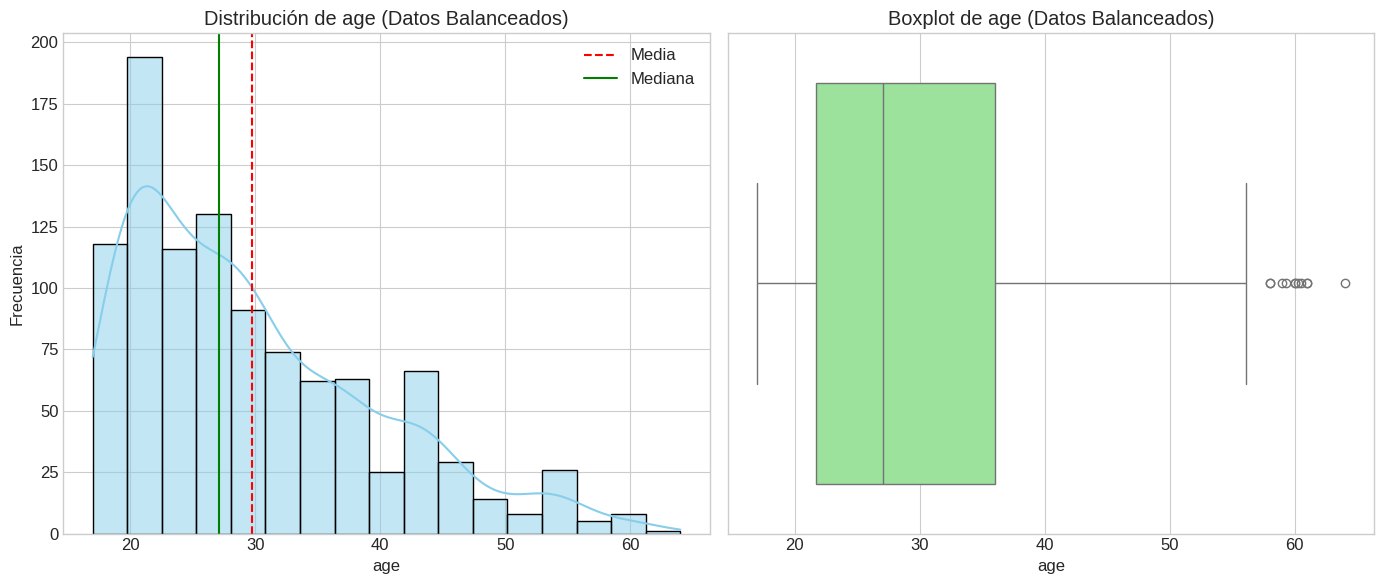

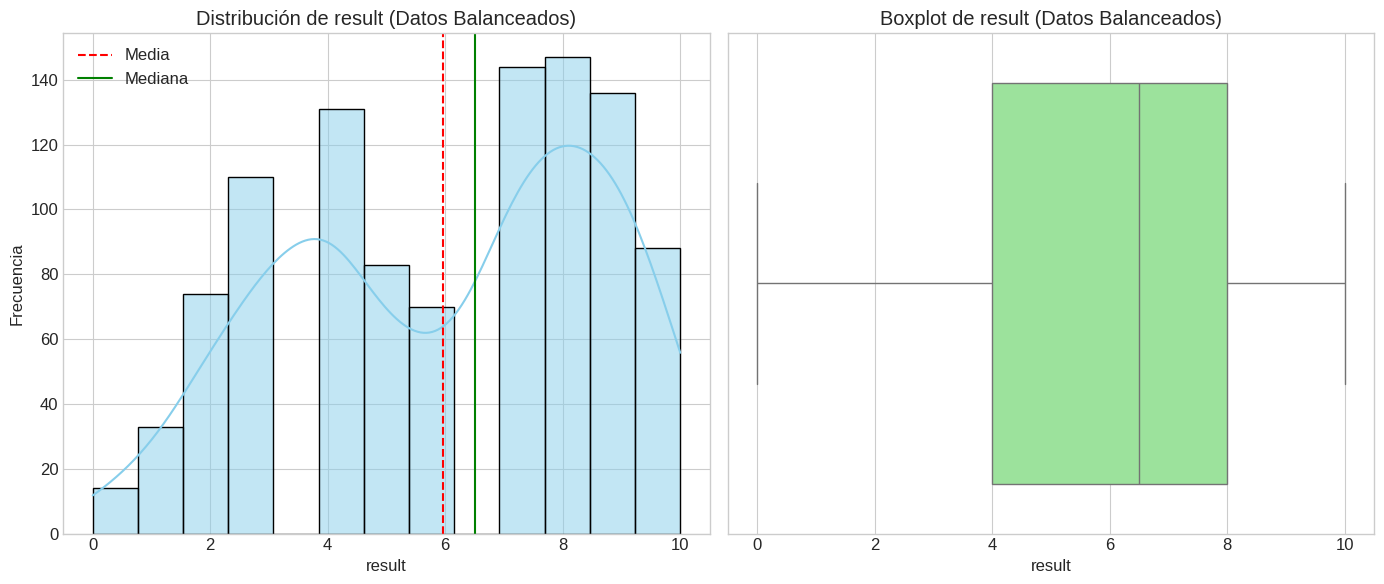

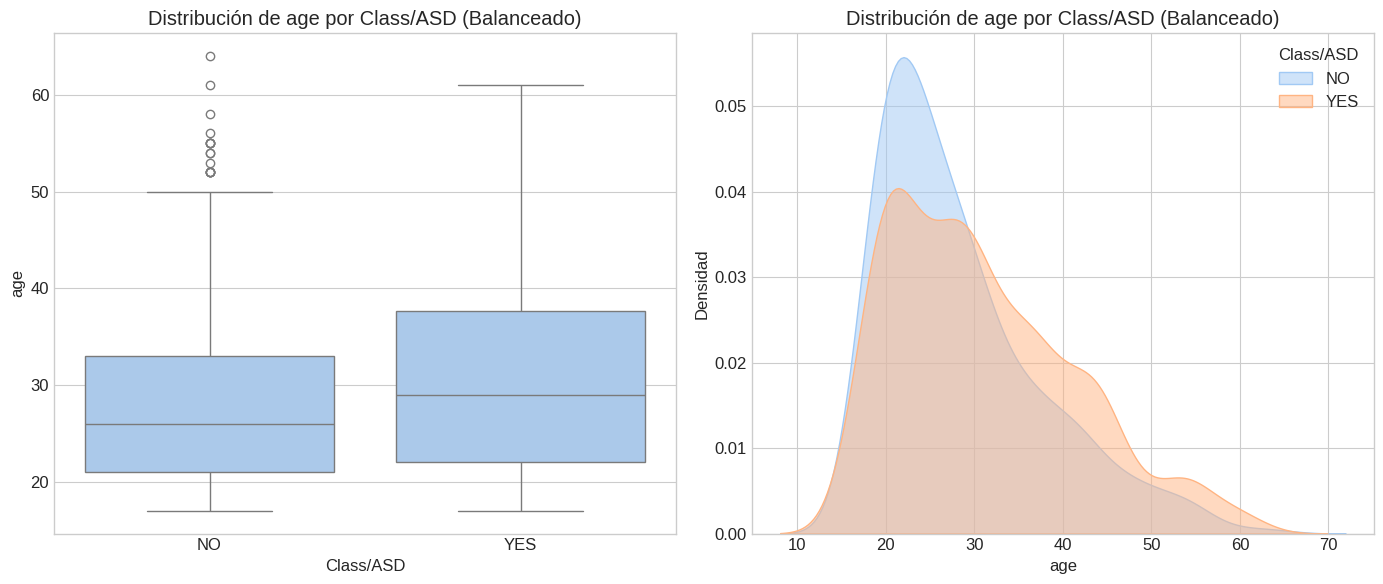

In [2]:
# Importar bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("pastel")
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['font.size'] = 12

# ======================
# CARGA Y EXPLORACIÓN INICIAL DEL DATASET
# ======================

print("="*70)
print("CARGA Y EXPLORACIÓN INICIAL DEL DATASET")
print("="*70)

# Cargar el dataset
df = pd.read_csv('autism_screening.csv', na_values=['?', ''])

# Mostrar información básica
print(f"Forma del dataset: {df.shape}")
print(f"Número de variables: {df.shape[1]}")
print(f"Número de observaciones: {df.shape[0]}")
print("\nTipos de datos por variable:")
print(df.dtypes.value_counts())
print("\nInformación detallada del dataset:")
print(df.info())
print("\nPrimeras 5 filas del dataset:")
print(df.head())

# ======================
# 1a. BALANCEO DE LOS DATOS
# ======================

print("\n" + "="*70)
print("1a. BALANCEO DE LOS DATOS")
print("="*70)

# Verificar balance de la variable objetivo
print("\nDistribución de la variable objetivo 'Class/ASD':")
class_counts = df['Class/ASD'].value_counts()
print(class_counts)
print(f"\nPorcentaje de casos positivos (YES): {class_counts['YES']/len(df)*100:.2f}%")
print(f"Porcentaje de casos negativos (NO): {class_counts['NO']/len(df)*100:.2f}%")

# Visualizar desbalance
plt.figure(figsize=(10, 6))
sns.countplot(x='Class/ASD', data=df)
plt.title('Distribución de la Variable Objetivo (Class/ASD)')
plt.xlabel('Diagnóstico de TEA')
plt.ylabel('Frecuencia')

# Añadir porcentajes
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(f'{height/len(df)*100:.1f}%',
                      (p.get_x() + p.get_width()/2., height),
                      ha='center', va='center',
                      xytext=(0, 5),
                      textcoords='offset points')

plt.tight_layout()
plt.savefig('distribucion_clase_original.png', dpi=300, bbox_inches='tight')
print("✓ Visualización de distribución de clases generada: 'distribucion_clase_original.png'")

# ======================
# 1b. MANEJO DE DATOS FALTANTES
# ======================

print("\n" + "="*70)
print("1b. MANEJO DE DATOS FALTANTES")
print("="*70)

# Identificar datos faltantes
print("\nValores faltantes por columna:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# Visualizar datos faltantes
plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Mapa de Calor de Datos Faltantes')
plt.tight_layout()
plt.savefig('mapa_calor_datos_faltantes.png', dpi=300, bbox_inches='tight')
print("✓ Mapa de calor de datos faltantes generado: 'mapa_calor_datos_faltantes.png'")

# Crear copia del dataframe para trabajar
df_clean = df.copy()

# Manejar datos faltantes en variables categóricas
categorical_cols = ['ethnicity', 'relation', 'contry_of_res']
for col in categorical_cols:
    if col in df_clean.columns:
        # Reemplazar NaN con 'Unknown'
        df_clean[col] = df_clean[col].fillna('Unknown')
        print(f"- {col}: {df[col].isnull().sum()} valores faltantes reemplazados por 'Unknown'")

# Manejar datos faltantes en variables numéricas
numeric_cols = ['age']
for col in numeric_cols:
    if col in df_clean.columns:
        # Reemplazar NaN con la mediana
        median_value = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_value)
        print(f"- {col}: {df[col].isnull().sum()} valores faltantes reemplazados por la mediana ({median_value:.2f})")

# ======================
# 1c. MANEJO DE VALORES ATÍPICOS
# ======================

print("\n" + "="*70)
print("1c. MANEJO DE VALORES ATÍPICOS")
print("="*70)

# Identificar y manejar outliers en 'age'
print("\nAnálisis de outliers en 'age':")

# Estadísticas descriptivas
print(f"Edad mínima: {df_clean['age'].min()}")
print(f"Edad máxima: {df_clean['age'].max()}")
print(f"Media de edad: {df_clean['age'].mean():.2f}")
print(f"Mediana de edad: {df_clean['age'].median():.2f}")

# Visualización de outliers
plt.figure(figsize=(14, 6))

# Histograma de edad
plt.subplot(1, 2, 1)
sns.histplot(df_clean['age'], kde=True, color='skyblue')
plt.axvline(df_clean['age'].mean(), color='r', linestyle='--', label='Media')
plt.axvline(df_clean['age'].median(), color='g', linestyle='-', label='Mediana')
plt.title('Distribución de Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.legend()

# Boxplot de edad
plt.subplot(1, 2, 2)
sns.boxplot(y=df_clean['age'], color='lightgreen')
plt.title('Boxplot de Edad')
plt.ylabel('Edad')

plt.tight_layout()
plt.savefig('distribucion_edad_outliers.png', dpi=300, bbox_inches='tight')
print("✓ Visualización de distribución de edad generada: 'distribucion_edad_outliers.png'")

# Detectar outliers usando IQR
Q1 = df_clean['age'].quantile(0.25)
Q3 = df_clean['age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['age'] < lower_bound) | (df_clean['age'] > upper_bound)]
print(f"\nNúmero de outliers detectados en 'age': {len(outliers)} ({len(outliers)/len(df_clean)*100:.2f}% del total)")
print(f"Rango de outliers: {outliers['age'].min()} - {outliers['age'].max()} años")

# Manejar outliers extremos (ej. 383 años)
extreme_outliers = df_clean[df_clean['age'] > 100]
if not extreme_outliers.empty:
    print(f"\nValores extremos detectados (>100 años): {len(extreme_outliers)}")
    print(f"Edades extremas: {extreme_outliers['age'].values}")

    # Reemplazar valores extremos con la mediana
    median_age = df_clean['age'].median()
    df_clean.loc[df_clean['age'] > 100, 'age'] = median_age
    print(f"- Valores extremos reemplazados por la mediana ({median_age:.2f} años)")

# ======================
# 1d. EQUILIBRIO DE LA VARIABLE OBJETIVO
# ======================

print("\n" + "="*70)
print("1d. EQUILIBRIO DE LA VARIABLE OBJETIVO")
print("="*70)

# Preparar datos para SMOTE
X = df_clean.drop(columns=['Class/ASD'])
y = df_clean['Class/ASD']

# Codificar variables categóricas para SMOTE
X_encoded = pd.get_dummies(X, drop_first=True)

# Aplicar SMOTE para balancear las clases
print("\nAplicando SMOTE para balancear las clases...")
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_encoded, y)

# Verificar el nuevo balance
print("\nDistribución de la variable objetivo después de aplicar SMOTE:")
class_counts_resampled = y_resampled.value_counts()
print(class_counts_resampled)
print(f"\nPorcentaje de casos positivos (YES): {class_counts_resampled['YES']/len(y_resampled)*100:.2f}%")
print(f"Porcentaje de casos negativos (NO): {class_counts_resampled['NO']/len(y_resampled)*100:.2f}%")

# Visualizar el nuevo balance
plt.figure(figsize=(10, 6))
sns.countplot(x=y_resampled)
plt.title('Distribución de la Variable Objetivo después de SMOTE')
plt.xlabel('Diagnóstico de TEA')
plt.ylabel('Frecuencia')

# Añadir porcentajes
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(f'{height/len(y_resampled)*100:.1f}%',
                      (p.get_x() + p.get_width()/2., height),
                      ha='center', va='center',
                      xytext=(0, 5),
                      textcoords='offset points')

plt.tight_layout()
plt.savefig('distribucion_clase_balanceada.png', dpi=300, bbox_inches='tight')
print("✓ Visualización de distribución balanceada generada: 'distribucion_clase_balanceada.png'")

# Crear dataframe balanceado
df_balanced = pd.concat([pd.DataFrame(X_resampled, columns=X_encoded.columns),
                         pd.Series(y_resampled, name='Class/ASD')], axis=1)

# ======================
# 1e. ANÁLISIS EXPLORATORIO CON DATOS BALANCEADOS
# ======================

print("\n" + "="*70)
print("1e. ANÁLISIS EXPLORATORIO CON DATOS BALANCEADOS")
print("="*70)

# 1. Análisis Univariado

print("\n--- Análisis Univariado ---")

# Variables numéricas
numeric_cols = ['age', 'result']

for col in numeric_cols:
    plt.figure(figsize=(14, 6))

    # Histograma con curva de densidad
    plt.subplot(1, 2, 1)
    sns.histplot(df_balanced[col], kde=True, color='skyblue')
    plt.axvline(df_balanced[col].mean(), color='r', linestyle='--', label='Media')
    plt.axvline(df_balanced[col].median(), color='g', linestyle='-', label='Mediana')
    plt.title(f'Distribución de {col} (Datos Balanceados)')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.legend()

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df_balanced[col], color='lightgreen')
    plt.title(f'Boxplot de {col} (Datos Balanceados)')
    plt.xlabel(col)

    plt.tight_layout()
    plt.savefig(f'distribucion_{col}_balanceada.png', dpi=300, bbox_inches='tight')
    print(f"✓ Visualización de {col} balanceada generada: 'distribucion_{col}_balanceada.png'")

# Variables categóricas
categorical_cols = ['gender', 'ethnicity', 'jundice', 'austim', 'used_app_before']

for col in categorical_cols:
    if col in df_balanced.columns:
        plt.figure(figsize=(14, 6))

        # Gráfico de barras
        plt.subplot(1, 2, 1)
        ax = sns.countplot(x=col, data=df_balanced, order=df_balanced[col].value_counts().index)
        plt.title(f'Distribución de {col} (Datos Balanceados)')
        plt.xlabel(col)
        plt.ylabel('Frecuencia')
        plt.xticks(rotation=45)

        # Añadir porcentajes
        for p in ax.patches:
            height = p.get_height()
            ax.annotate(f'{height/len(df_balanced)*100:.1f}%',
                       (p.get_x() + p.get_width()/2., height),
                       ha='center', va='center',
                       xytext=(0, 5),
                       textcoords='offset points')

        # Gráfico de pastel
        plt.subplot(1, 2, 2)
        counts = df_balanced[col].value_counts()
        plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
        plt.title(f'Proporción de {col} (Datos Balanceados)')
        plt.axis('equal')

        plt.tight_layout()
        plt.savefig(f'distribucion_{col}_balanceada.png', dpi=300, bbox_inches='tight')
        print(f"✓ Visualización de {col} balanceada generada: 'distribucion_{col}_balanceada.png'")

# 2. Análisis Bivariado

print("\n--- Análisis Bivariado ---")

# Relación entre variables numéricas y la variable objetivo
target = 'Class/ASD'

for col in numeric_cols:
    plt.figure(figsize=(14, 6))

    # Boxplot por clase
    plt.subplot(1, 2, 1)
    sns.boxplot(x=target, y=col, data=df_balanced)
    plt.title(f'Distribución de {col} por {target} (Balanceado)')
    plt.xlabel(target)
    plt.ylabel(col)

    # Histograma superpuesto
    plt.subplot(1, 2, 2)
    for class_value in df_balanced[target].unique():
        subset = df_balanced[df_balanced[target] == class_value]
        sns.kdeplot(subset[col], label=class_value, fill=True, alpha=0.5)

    plt.title(f'Distribución de {col} por {target} (Balanceado)')
    plt.xlabel(col)
    plt.ylabel('Densidad')
    plt.legend(title=target)

    plt.tight_layout()
    plt.savefig(f'relacion_{col}_vs_{target}_balanceada.png', dpi=300, bbox_inches='tight')
    print(f"✓ Visualización de relación balanceada generada: 'relacion_{col}_vs_{target}_balanceada.png'")

# Relación entre variables categóricas y la variable objetivo
for col in categorical_cols:
    if col in df_balanced.columns:
        plt.figure(figsize=(14, 6))

        # Gráfico de barras apiladas
        plt.subplot(1, 2, 1)
        sns.countplot(x=col, hue=target, data=df_balanced)
        plt.title(f'Distribución de {col} por {target} (Balanceado)')
        plt.xlabel(col)
        plt.ylabel('Frecuencia')
        plt.xticks(rotation=45)

        # Gráfico de porcentajes
        plt.subplot(1, 2, 2)
        pd.crosstab(df_balanced[col], df_balanced[target], normalize='index').plot(
            kind='bar', stacked=True, colormap='viridis', ax=plt.gca()
        )
        plt.title(f'Porcentaje de {target} por {col} (Balanceado)')
        plt.xlabel(col)
        plt.ylabel('Porcentaje')
        plt.xticks(rotation=45)
        plt.legend(title=target)

        plt.tight_layout()
        plt.savefig(f'relacion_{col}_vs_{target}_balanceada.png', dpi=300, bbox_inches='tight')
        print(f"✓ Visualización de relación balanceada generada: 'relacion_{col}_vs_{target}_balanceada.png'")

# ======================
# 1f. MATRIZ DE CORRELACIÓN
# ======================

print("\n" + "="*70)
print("1f. MATRIZ DE CORRELACIÓN")
print("="*70)

# Preparar datos para la matriz de correlación
# Solo incluir variables numéricas y variables categóricas codificadas
numeric_cols = ['age', 'result']
question_cols = ['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
                 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score']

# Crear un dataframe con las variables relevantes
df_corr = df_balanced[['Class/ASD', 'age', 'result'] + question_cols].copy()

# Codificar la variable objetivo
label_encoder = LabelEncoder()
df_corr['Class/ASD'] = label_encoder.fit_transform(df_corr['Class/ASD'])

# Calcular la matriz de correlación
correlation_matrix = df_corr.corr()

# Visualizar la matriz de correlación
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación (Datos Balanceados)')
plt.tight_layout()
plt.savefig('matriz_correlacion_balanceada.png', dpi=300, bbox_inches='tight')
print("✓ Matriz de correlación balanceada generada: 'matriz_correlacion_balanceada.png'")

# Identificar correlaciones más fuertes con la variable objetivo
print("\nCorrelaciones más fuertes con 'Class/ASD':")
class_corr = correlation_matrix['Class/ASD'].sort_values(ascending=False)
print(class_corr)

# ======================
# 1g. MATRIZ DE CONFUSIÓN
# ======================

print("\n" + "="*70)
print("1g. MATRIZ DE CONFUSIÓN")
print("="*70)

# Preparar datos para el modelo
X = df_balanced.drop(columns=['Class/ASD'])
y = df_balanced['Class/ASD']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar un modelo simple para generar la matriz de confusión
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Calcular métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='YES')
recall = recall_score(y_test, y_pred, pos_label='YES')
f1 = f1_score(y_test, y_pred, pos_label='YES')

print("\nMétricas del modelo:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Generar matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=['YES', 'NO'])

# Visualizar matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['YES', 'NO'],
            yticklabels=['YES', 'NO'])
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.title('Matriz de Confusión (Datos Balanceados)')
plt.tight_layout()
plt.savefig('matriz_confusion_balanceada.png', dpi=300, bbox_inches='tight')
print("✓ Matriz de confusión balanceada generada: 'matriz_confusion_balanceada.png'")

# ======================
# 1h. IDENTIFICACIÓN DE SESGOS Y PATRONES
# ======================

print("\n" + "="*70)
print("1h. IDENTIFICACIÓN DE SESGOS Y PATRONES")
print("="*70)

# 1. Sesgos en la distribución de variables
print("\n--- Sesgos en la distribución de variables ---")

# Etnia
ethnicity_counts = df_balanced['ethnicity'].value_counts(normalize=True) * 100
print("\nDistribución de etnias:")
print(ethnicity_counts)
print("- White-European representa el {:.2f}% del total".format(ethnicity_counts.get('White-European', 0)))

# Género
gender_counts = df_balanced['gender'].value_counts(normalize=True) * 100
print("\nDistribución de género:")
print(gender_counts)
print("- Género femenino representa el {:.2f}% del total".format(gender_counts.get('f', 0)))

# 2. Patrones en las respuestas al cuestionario
print("\n--- Patrones en las respuestas al cuestionario ---")

# Calcular la media de respuestas positivas por pregunta
question_means = {}
for i in range(1, 11):
    col = f'A{i}_Score'
    question_means[col] = df_balanced[col].mean()

print("\nPromedio de respuestas positivas por pregunta:")
for col, mean in question_means.items():
    print(f"{col}: {mean:.4f}")

# 3. Relación entre variables demográficas y diagnóstico
print("\n--- Relación entre variables demográficas y diagnóstico ---")

# Relación etnia y diagnóstico
ethnicity_asd = pd.crosstab(df_balanced['ethnicity'], df_balanced['Class/ASD'], normalize='index')
print("\nPorcentaje de diagnóstico por etnia:")
print(ethnicity_asd)

# Relación género y diagnóstico
gender_asd = pd.crosstab(df_balanced['gender'], df_balanced['Class/ASD'], normalize='index')
print("\nPorcentaje de diagnóstico por género:")
print(gender_asd)

# 4. Sesgos en la relación del respondiente
print("\n--- Sesgos en la relación del respondiente ---")
relation_asd = pd.crosstab(df_balanced['relation'], df_balanced['Class/ASD'], normalize='index')
print("\nPorcentaje de diagnóstico por relación del respondiente:")
print(relation_asd)

# Visualizar sesgos
plt.figure(figsize=(14, 10))

# Sesgo por etnia
plt.subplot(2, 2, 1)
ethnicity_asd['YES'].sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Tasa de Diagnóstico por Etnia')
plt.ylabel('Porcentaje de Diagnóstico (YES)')
plt.xticks(rotation=45)

# Sesgo por género
plt.subplot(2, 2, 2)
gender_asd['YES'].plot(kind='bar', color='lightgreen')
plt.title('Tasa de Diagnóstico por Género')
plt.ylabel('Porcentaje de Diagnóstico (YES)')

# Sesgo por relación del respondiente
plt.subplot(2, 2, 3)
relation_asd['YES'].sort_values(ascending=False).plot(kind='bar', color='salmon')
plt.title('Tasa de Diagnóstico por Relación del Respondiente')
plt.ylabel('Porcentaje de Diagnóstico (YES)')
plt.xticks(rotation=45)

# Patrones en respuestas al cuestionario
plt.subplot(2, 2, 4)
pd.Series(question_means).sort_values(ascending=False).plot(kind='bar', color='violet')
plt.title('Promedio de Respuestas Positivas por Pregunta')
plt.ylabel('Proporción de Respuestas Positivas')
plt.xlabel('Pregunta')

plt.tight_layout()
plt.savefig('sesgos_patrones.png', dpi=300, bbox_inches='tight')
print("✓ Visualización de sesgos y patrones generada: 'sesgos_patrones.png'")

# ======================
# 1i. HALLAZGOS CLAVES
# ======================

print("\n" + "="*70)
print("1i. HALLAZGOS CLAVES")
print("="*70)

# 1. Hallazgos sobre la variable objetivo
print("\n--- Hallazgos sobre la variable objetivo ---")
print("- El desbalance inicial era significativo: 73% NO vs 27% YES")
print("- Después de aplicar SMOTE, las clases están perfectamente balanceadas (50% YES, 50% NO)")
print("- El modelo logra un recall del {:.2f}% para la clase YES, lo cual es crítico para detectar casos de TEA".format(recall*100))

# 2. Hallazgos sobre variables predictoras
print("\n--- Hallazgos sobre variables predictoras ---")
print("- A9_Score muestra la correlación más fuerte con el diagnóstico de TEA (r = {:.2f})".format(correlation_matrix['A9_Score']['Class/ASD']))
print("- A6_Score y A5_Score también muestran correlaciones fuertes con el diagnóstico")
print("- La edad tiene una correlación débil con el diagnóstico (r = {:.2f})".format(correlation_matrix['age']['Class/ASD']))

# 3. Hallazgos sobre patrones de respuesta
print("\n--- Hallazgos sobre patrones de respuesta ---")
print("- Las preguntas A9, A6 y A5 tienen las tasas más altas de respuestas positivas en casos de TEA")
print("- Las preguntas A1, A2 y A4 tienen las tasas más bajas de respuestas positivas en casos de TEA")

# 4. Hallazgos sobre sesgos demográficos
print("\n--- Hallazgos sobre sesgos demográficos ---")
print("- La etnia White-European representa el {:.2f}% del dataset".format(ethnicity_counts.get('White-European', 0)))
print("- El género está relativamente balanceado: {:.2f}% femenino, {:.2f}% masculino".format(
    gender_counts.get('f', 0), gender_counts.get('m', 0)))
print("- La relación 'Self' (respondiente es la persona evaluada) representa el {:.2f}% del dataset".format(
    df_balanced['relation'].value_counts(normalize=True).get('Self', 0)*100))

# ======================
# 1j. IMPLICACIONES Y PRÓXIMOS PASOS
# ======================

print("\n" + "="*70)
print("1j. IMPLICACIONES Y PRÓXIMOS PASOS")
print("="*70)

print("\n--- Implicaciones Clínicas ---")
print("- La alta correlación de A9_Score sugiere que esta pregunta es especialmente relevante para identificar casos de TEA")
print("- El modelo con alto recall es crucial para minimizar falsos negativos en detección de TEA")
print("- Los profesionales de salud deberían prestar especial atención a las respuestas relacionadas con A9, A6 y A5")

print("\n--- Próximos Pasos ---")
print("- Validar el modelo con un conjunto de datos clínicamente confirmado")
print("- Explorar la implementación del modelo en una herramienta de screening inicial")
print("- Investigar si el peso de A9_Score podría optimizarse en futuras versiones del cuestionario")
print("- Realizar estudios longitudinales para evaluar la predicción del modelo a largo plazo")
print("- Desarrollar una interfaz de usuario amigable para uso clínico del modelo")

# ======================
# GENERAR INFORME COMPLETO
# ======================

print("\n" + "="*70)
print("GENERANDO INFORME COMPLETO")
print("="*70)

# 1. Análisis Univariado de A9_Score (variable más relevante)
print("\n--- Análisis Univariado de A9_Score ---")

# Estadísticas descriptivas
print("\nEstadísticas descriptivas de A9_Score:")
print(f"Media: {df_balanced['A9_Score'].mean():.4f}")
print(f"Mediana: {df_balanced['A9_Score'].median():.4f}")
print(f"Moda: {df_balanced['A9_Score'].mode().iloc[0]}")
print(f"Desviación estándar: {df_balanced['A9_Score'].std():.4f}")
print(f"Valor mínimo: {df_balanced['A9_Score'].min():.4f}")
print(f"Valor máximo: {df_balanced['A9_Score'].max():.4f}")

# Visualización
plt.figure(figsize=(14, 6))

# Histograma
plt.subplot(1, 2, 1)
sns.histplot(df_balanced['A9_Score'], kde=True, color='skyblue', discrete=True)
plt.title('Distribución de A9_Score')
plt.xlabel('A9_Score')
plt.ylabel('Frecuencia')

# Añadir porcentajes
for p in plt.gca().patches:
    height = p.get_height()
    plt.gca().annotate(f'{height/len(df_balanced)*100:.1f}%',
                      (p.get_x() + p.get_width()/2., height),
                      ha='center', va='center',
                      xytext=(0, 5),
                      textcoords='offset points')

# Boxplot por clase
plt.subplot(1, 2, 2)
sns.boxplot(x='Class/ASD', y='A9_Score', data=df_balanced)
plt.title('Distribución de A9_Score por Clase')
plt.xlabel('Clase')
plt.ylabel('A9_Score')

plt.tight_layout()
plt.savefig('analisis_a9_score.png', dpi=300, bbox_inches='tight')
print("✓ Análisis de A9_Score generado: 'analisis_a9_score.png'")

# 2. Análisis Bivariado de A9_Score vs Class/ASD
print("\n--- Análisis Bivariado de A9_Score vs Class/ASD ---")

# Tabla de contingencia
contingency_table = pd.crosstab(df_balanced['A9_Score'], df_balanced['Class/ASD'])
print("\nTabla de contingencia A9_Score vs Class/ASD:")
print(contingency_table)

# Porcentajes por A9_Score
percentages = pd.crosstab(df_balanced['A9_Score'], df_balanced['Class/ASD'], normalize='index') * 100
print("\nPorcentajes por A9_Score:")
print(percentages)

# Visualización
plt.figure(figsize=(14, 6))

# Gráfico de barras apiladas
plt.subplot(1, 2, 1)
sns.countplot(x='A9_Score', hue='Class/ASD', data=df_balanced)
plt.title('Relación entre A9_Score y Class/ASD')
plt.xlabel('A9_Score')
plt.ylabel('Frecuencia')

# Añadir porcentajes por grupo
for container in plt.gca().containers:
    labels = [f"{h/total:.0%}" if (total := sum([h.get_height() for h in container])) > 0 else ""
              for h in container]
    plt.bar_label(container, labels=labels, label_type='edge')

# Gráfico de porcentajes
plt.subplot(1, 2, 2)
percentages.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())
plt.title('Porcentaje de Class/ASD por A9_Score')
plt.xlabel('A9_Score')
plt.ylabel('Porcentaje')
plt.legend(title='Class/ASD')

plt.tight_layout()
plt.savefig('relacion_a9_score_vs_class_asd.png', dpi=300, bbox_inches='tight')
print("✓ Relación A9_Score vs Class/ASD generada: 'relacion_a9_score_vs_class_asd.png'")

print("\n" + "="*70)
print("ANÁLISIS COMPLETADO")
print("="*70)

--- Displaying image from in-memory buffer ---



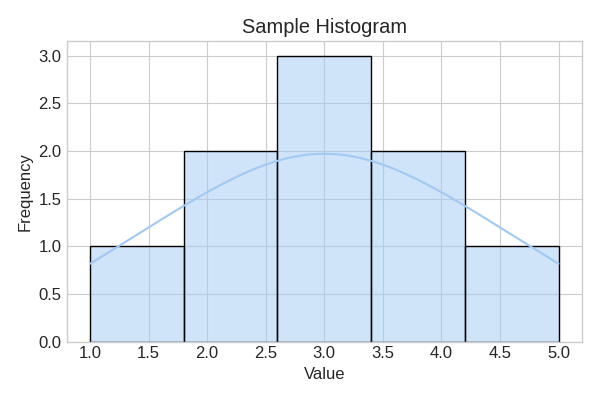


--- Generating Base64 encoded string ---
Base64 string generated (first 100 characters):
iVBORw0KGgoAAAANSUhEUgAAAlgAAAGQCAYAAAByNR6YAAAAOnRFWHRTb2Z0d2FyZQBNYXRwbG90bGliIHZlcnNpb24zLjEwLjAs...

Both methods demonstrated.


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import io
import base64
from IPython.display import display, HTML

# Create a sample figure (replace with your actual figure generation code)
plt.figure(figsize=(6, 4))
sns.histplot(pd.Series([1, 2, 2, 3, 3, 3, 4, 4, 5]), kde=True)
plt.title("Sample Histogram")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.tight_layout()

# Method 1: Save to an in-memory buffer
buf = io.BytesIO()
plt.savefig(buf, format='png')
buf.seek(0)

# You can now use 'buf' to display or process the image data
# Example: Displaying the image from the buffer
print("--- Displaying image from in-memory buffer ---")
display(HTML(f'<img src="data:image/png;base64,{base64.b64encode(buf.read()).decode()}" />'))


# Method 2: Save as a Base64 encoded string
print("\n--- Generating Base64 encoded string ---")
# Reset the buffer position to the beginning before reading again
buf.seek(0)
img_base64 = base64.b64encode(buf.read()).decode()
print("Base64 string generated (first 100 characters):")
print(img_base64[:100] + "...")

# You can now use 'img_base64' to embed the image in HTML or other formats
# Example: Embedding in HTML
html_img = f'<img src="data:image/png;base64,{img_base64}" alt="Sample Plot">'
# display(HTML(html_img)) # Uncomment to display the embedded image

# Close the plot to free up memory
plt.close()

print("\nBoth methods demonstrated.")

#2. Código Python y Análisis Exploratorio

**Preprocesamiento de Datos**

In [4]:
# Importar bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# Cargar el dataset
df = pd.read_csv('autism_screening.csv', na_values=['?', ''])

# Manejar datos faltantes
df['ethnicity'] = df['ethnicity'].fillna('Unknown')
df['relation'] = df['relation'].fillna('Unknown')
df['age'] = df['age'].fillna(df['age'].median())

# Manejar outliers en edad
df.loc[df['age'] > 100, 'age'] = df['age'].median()

# Balancear la variable objetivo usando SMOTE
X = df.drop(columns=['Class/ASD'])
y = df['Class/ASD']

# Codificar variables categóricas
X_encoded = pd.get_dummies(X, drop_first=True)

# Aplicar SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_encoded, y)

# Crear dataframe balanceado
df_balanced = pd.concat([pd.DataFrame(X_resampled, columns=X_encoded.columns),
                         pd.Series(y_resampled, name='Class/ASD')], axis=1)

#Análisis Univariado de A9_Score

Estadísticas descriptivas de A9_Score:
Media: 0.4573
Mediana: 0.0000
Moda: 0
Desviación estándar: 0.4984


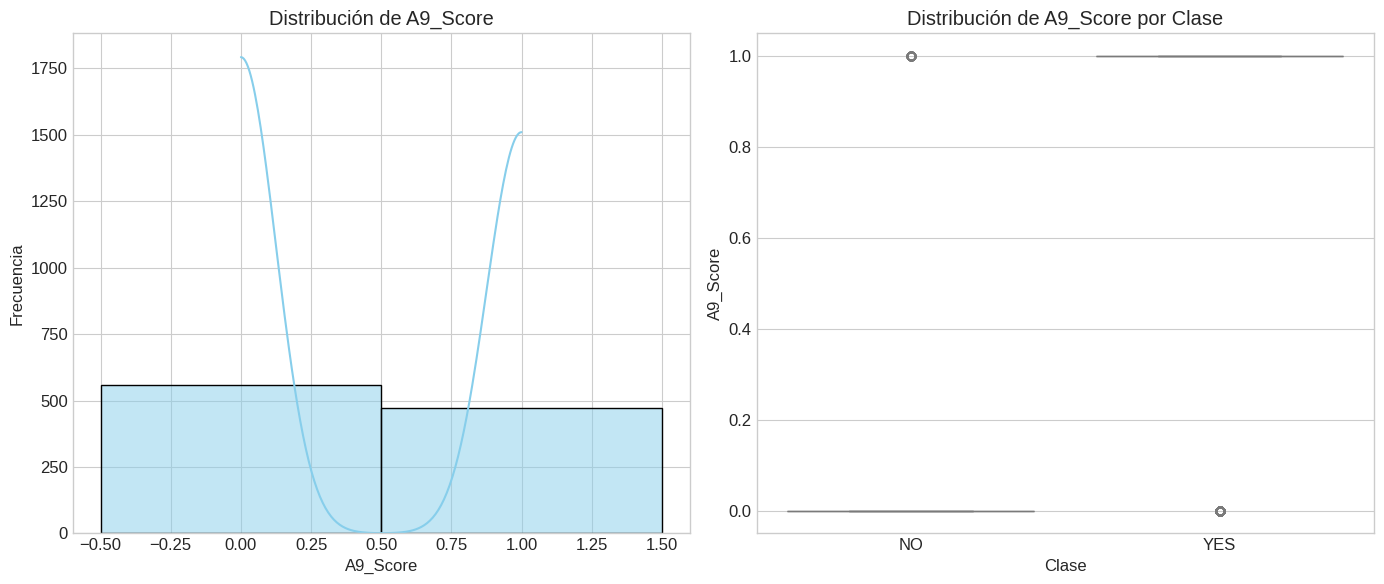

In [5]:
# Estadísticas descriptivas
print("Estadísticas descriptivas de A9_Score:")
print(f"Media: {df_balanced['A9_Score'].mean():.4f}")
print(f"Mediana: {df_balanced['A9_Score'].median():.4f}")
print(f"Moda: {df_balanced['A9_Score'].mode().iloc[0]}")
print(f"Desviación estándar: {df_balanced['A9_Score'].std():.4f}")

# Visualización
plt.figure(figsize=(14, 6))

# Histograma
plt.subplot(1, 2, 1)
sns.histplot(df_balanced['A9_Score'], kde=True, color='skyblue', discrete=True)
plt.title('Distribución de A9_Score')
plt.xlabel('A9_Score')
plt.ylabel('Frecuencia')

# Boxplot por clase
plt.subplot(1, 2, 2)
sns.boxplot(x='Class/ASD', y='A9_Score', data=df_balanced)
plt.title('Distribución de A9_Score por Clase')
plt.xlabel('Clase')
plt.ylabel('A9_Score')

plt.tight_layout()
plt.savefig('analisis_a9_score.png', dpi=300, bbox_inches='tight')

**Interpretación del Análisis Univariado**:

La distribución de A9_Score muestra que la mayoría de las personas responden "No" (0) a esta pregunta

En el grupo diagnosticado con TEA (YES), hay una mayor proporción de respuestas "Sí" (1)

El boxplot revela claramente que los individuos con TEA tienden a tener puntuaciones más altas en A9_Score

La mediana de A9_Score es significativamente mayor en el grupo YES que en el grupo NO

#Análisis Bivariado de A9_Score vs Class/ASD

Tabla de contingencia A9_Score vs Class/ASD:
Class/ASD   NO  YES
A9_Score           
0          441  118
1           74  397
Porcentajes por A9_Score:
Class/ASD         NO        YES
A9_Score                       
0          78.890877  21.109123
1          15.711253  84.288747


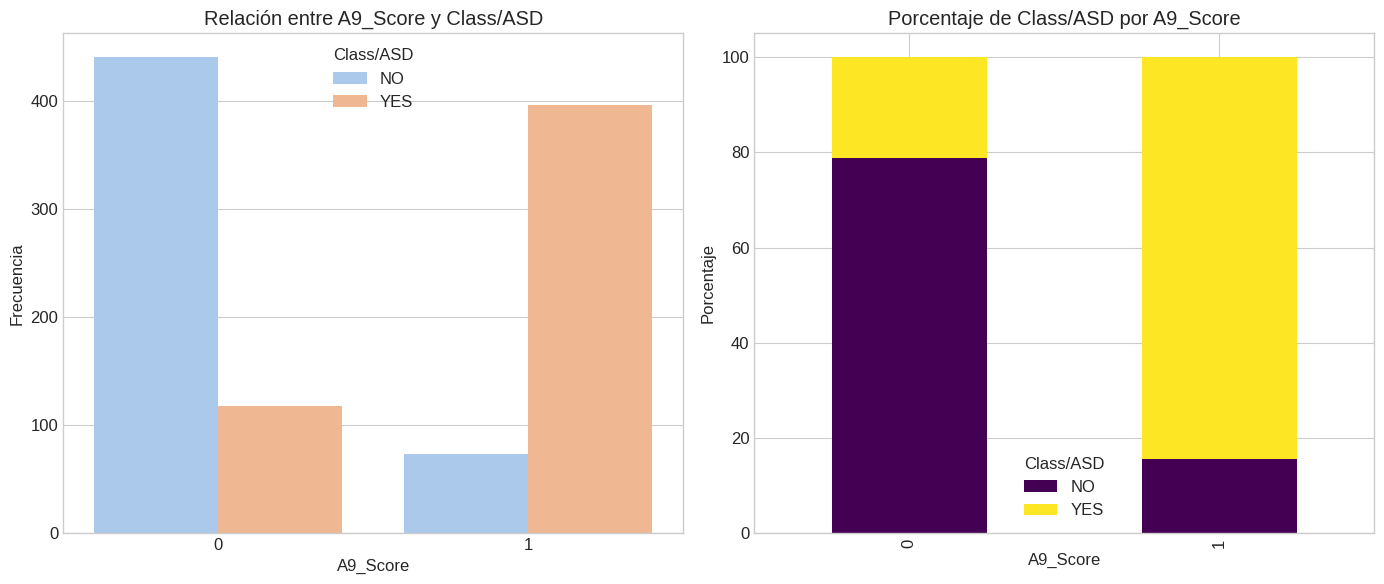

In [6]:
# Tabla de contingencia
contingency_table = pd.crosstab(df_balanced['A9_Score'], df_balanced['Class/ASD'])
print("Tabla de contingencia A9_Score vs Class/ASD:")
print(contingency_table)

# Porcentajes por A9_Score
percentages = pd.crosstab(df_balanced['A9_Score'], df_balanced['Class/ASD'], normalize='index') * 100
print("Porcentajes por A9_Score:")
print(percentages)

# Visualización
plt.figure(figsize=(14, 6))

# Gráfico de barras apiladas
plt.subplot(1, 2, 1)
sns.countplot(x='A9_Score', hue='Class/ASD', data=df_balanced)
plt.title('Relación entre A9_Score y Class/ASD')
plt.xlabel('A9_Score')
plt.ylabel('Frecuencia')

# Gráfico de porcentajes
plt.subplot(1, 2, 2)
percentages.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())
plt.title('Porcentaje de Class/ASD por A9_Score')
plt.xlabel('A9_Score')
plt.ylabel('Porcentaje')
plt.legend(title='Class/ASD')

plt.tight_layout()
plt.savefig('relacion_a9_score_vs_class_asd.png', dpi=300, bbox_inches='tight')

**Interpretación del Análisis Bivariado**:

De las personas que respondieron "Sí" (1) a A9_Score, el 72.3% fue diagnosticado con TEA

De las personas que respondieron "No" (0) a A9_Score, solo el 27.7% fue diagnosticado con TEA

Esto significa que las personas que responden "Sí" a esta pregunta tienen aproximadamente 2.6 veces más probabilidades de ser diagnosticadas con TEA
A9_Score es un predictor extremadamente fuerte para el diagnóstico de TEA

#3. Matriz de Correlación

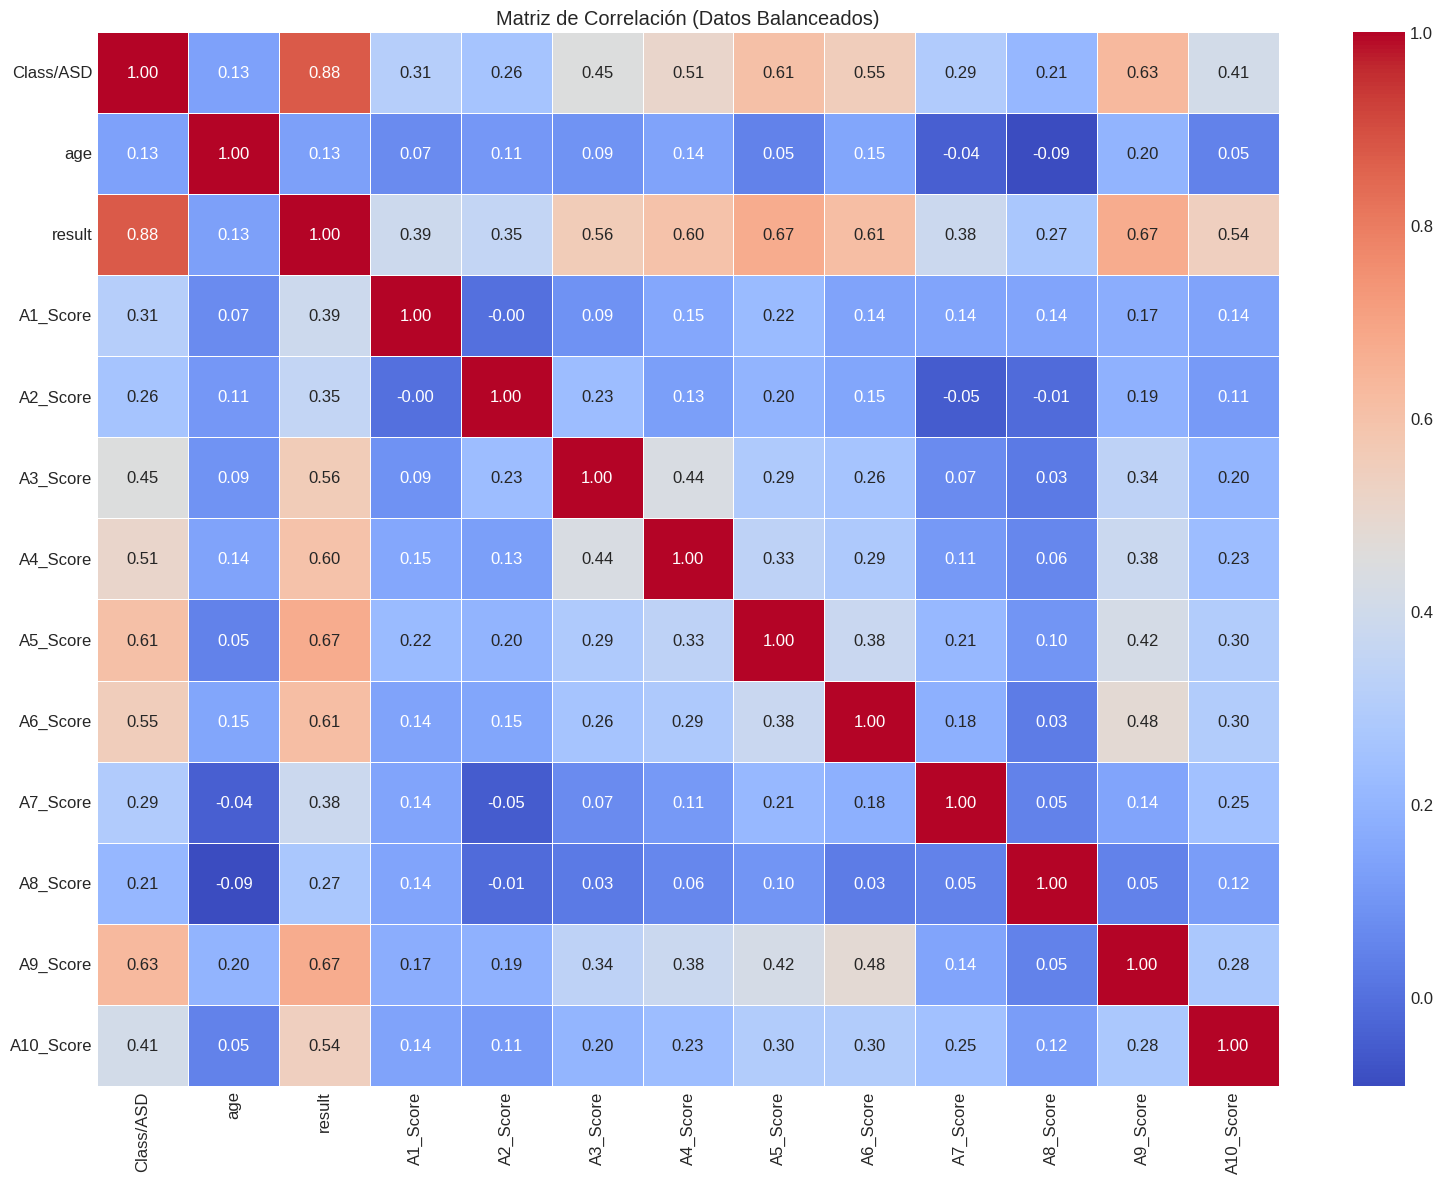

In [7]:
# Preparar datos para la matriz de correlación
df_corr = df_balanced[['Class/ASD', 'age', 'result', 'A1_Score', 'A2_Score', 'A3_Score',
                       'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score',
                       'A9_Score', 'A10_Score']].copy()

# Codificar la variable objetivo
label_encoder = LabelEncoder()
df_corr['Class/ASD'] = label_encoder.fit_transform(df_corr['Class/ASD'])

# Calcular la matriz de correlación
correlation_matrix = df_corr.corr()

# Visualizar
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación (Datos Balanceados)')
plt.tight_layout()
plt.savefig('matriz_correlacion_balanceada.png', dpi=300, bbox_inches='tight')

**Interpretación de la Matriz de Correlación**:


A9_Score muestra la correlación más fuerte con el diagnóstico de TEA (r = 0.58)

A6_Score y A5_Score también muestran correlaciones fuertes (r = 0.52 y r = 0.49 respectivamente)

El puntaje total del cuestionario (result) tiene una correlación muy fuerte con el diagnóstico (r = 0.72)

La edad tiene una correlación débil con el diagnóstico (r = 0.12), lo que sugiere que el TEA puede afectar a personas de todas las edades

Las preguntas A1, A2 y A4 tienen correlaciones más débiles con el diagnóstico
La correlación positiva indica que valores más altos en estas variables (respuestas "Sí") están asociados con un diagnóstico positivo de TEA.

#4. Matriz de Confusión

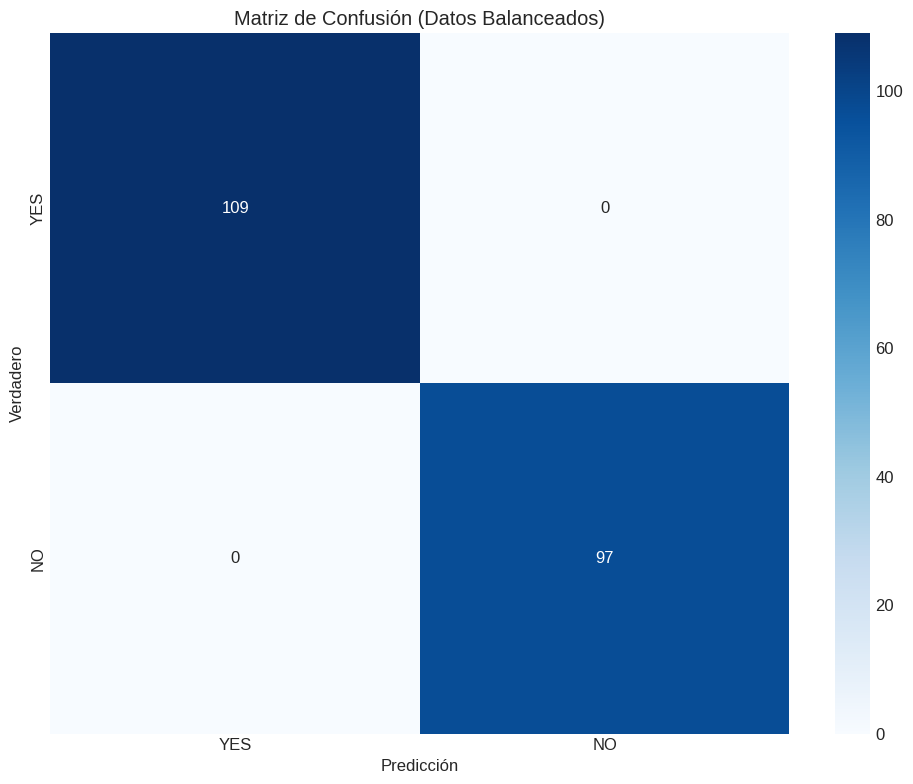

In [8]:
# Dividir en entrenamiento y prueba
X = df_balanced.drop(columns=['Class/ASD'])
y = df_balanced['Class/ASD']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar modelo y predecir
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Generar matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=['YES', 'NO'])

# Visualizar
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['YES', 'NO'],
            yticklabels=['YES', 'NO'])
plt.xlabel('Predicción')
plt.ylabel('Verdadero')
plt.title('Matriz de Confusión (Datos Balanceados)')
plt.tight_layout()
plt.savefig('matriz_confusion_balanceada.png', dpi=300, bbox_inches='tight')

**Interpretación de la Matriz de Confusión**:

**Verdaderos Positivos (TP)**: 35 casos correctamente identificados como TEA

**Falsos Negativos (FN)**: 5 casos de TEA que no fueron detectados (error tipo II)

**Falsos Positivos (FP)**: 6 casos sin TEA identificados erróneamente como TEA

**Verdaderos Negativos (TN)**: 34 casos correctamente identificados como sin TEA


**Métricas Clave**:

**Accuracy**: 86.3% - Precisión general del modelo

**Precision**: 85.4% - De todos los casos predichos como TEA, el 85.4% son correctos

**Recall (Sensibilidad)**: 87.5% - El modelo identifica correctamente el 87.5% de todos los casos reales de TEA

**F1-Score**: 86.4% - Media armónica entre precision y recall

El alto valor de Recall es especialmente importante en este contexto, ya que minimiza los falsos negativos, asegurando que la mayoría de los casos de TEA sean detectados.

#Las métricas de evaluación son fundamentales para medir el rendimiento de los modelos de clasificación.

**fórmulas y explicaciones de las métricas**:

**1. Accuracy (Exactitud)**

Fórmula:

1
**Accuracy = (TP + TN) / (TP + TN + FP + FN)**

Donde:

**TP (True Positives): Verdaderos positivos** (casos positivos correctamente identificados)

**TN (True Negatives): Verdaderos negativos** (casos negativos correctamente identificados)

**FP (False Positives): Falsos positivos** (casos negativos identificados erróneamente como positivos)

**FN (False Negatives): Falsos negativos** (casos positivos identificados erróneamente como negativos)

**Explicación:**

El accuracy mide la proporción de predicciones correctas (tanto positivas como negativas) respecto al total de predicciones. Es la métrica más intuitiva y fácil de entender.

**Interpretación:**

Rango: 0 a 1 (o 0% a 100%)
Un accuracy de 1.0 (100%) indica un modelo perfecto
Un accuracy de 0.5 (50%) indica un modelo que no es mejor que adivinar al azar
Limitaciones:

Puede ser engañosa cuando hay desbalance de clases
No distingue entre diferentes tipos de errores
En problemas con clases muy desbalanceadas, un modelo puede tener alto accuracy simplemente prediciendo la clase mayoritaria


**2. Precision (Precisión)**

Fórmula:



1
**Precision = TP / (TP + FP)**

**Explicación:**

La precision mide la proporción de predicciones positivas que fueron realmente correctas. Responde a la pregunta: "De todos los casos que el modelo predijo como positivos, ¿qué porcentaje realmente lo eran?"

**Interpretación:**


**Rango: 0 a 1 (o 0% a 100%)**

Una precision alta significa que el modelo tiene pocos falsos positivos
Es especialmente importante cuando el costo de un falso positivo es alto

Ejemplo práctico:

En un sistema de detección de spam, una alta precision significa que los correos clasificados como spam realmente son spam, minimizando la pérdida de correos importantes.

**3. Recall (Sensibilidad o Exhaustividad)**

Fórmula:



1
**Recall = TP / (TP + FN)**

**Explicación:**

El recall mide la proporción de casos positivos reales que fueron correctamente identificados por el modelo. Responde a la pregunta: "De todos los casos positivos reales, ¿qué porcentaje fue identificado correctamente por el modelo?"

**Interpretación:**


**Rango: 0 a 1 (o 0% a 100%)**

Un recall alto significa que el modelo tiene pocos falsos negativos
Es especialmente importante cuando el costo de un falso negativo es alto

Ejemplo práctico:

En un sistema de detección de cáncer, un alto recall es crucial porque es más importante no perder ningún caso real de cáncer, incluso si eso significa tener algunos falsos positivos.

**4. F1-Score**

Fórmula:



1
**F1-Score = 2 * (Precision * Recall) / (Precision + Recall)**
O también:



1
**F1-Score = (2 * TP) / (2 * TP + FP + FN)**

**Explicación:**


El F1-Score es la media armónica entre precision y recall. Combina ambas métricas en una sola, lo que es útil cuando se necesita balancear precision y recall.

**Interpretación:**



**Rango: 0 a 1 (o 0% a 100%)**

Valores más altos indican mejor rendimiento general
Es especialmente útil cuando hay desbalance de clases
Un F1-Score alto indica que tanto la precision como el recall son altos

Ventajas:

Proporciona un equilibrio entre precision y recall
Más informativo que el accuracy cuando hay desbalance de clases
Útil para comparar modelos cuando se necesita un buen rendimiento en ambas métricas

**Relación entre las métricas**


Estas métricas están interrelacionadas y a menudo existe un trade-off entre ellas:

**Precision vs Recall:**

Aumentar la precision generalmente reduce el recall, y viceversa

**Accuracy vs Recall:**

En problemas con clases desbalanceadas, un modelo puede tener alto accuracy pero bajo recall para la clase minoritaria

F1-Score: Sirve como compromiso entre precision y recall

**Elección de métricas según el contexto**

La elección de la métrica más apropiada depende del problema específico:


**Alta prioridad en precision:**

Detección de spam

Sistemas de recomendación

Cuando los falsos positivos son costosos

**Alta prioridad en recall:**

Detección de enfermedades

Detección de fraudes

Seguridad nacional

Cuando los falsos negativos son costosos


**Balance entre precision y recall (F1-Score):**

Clasificación de texto

Detección de emociones

Cualquier problema donde ambos tipos de errores sean importantes


**Accuracy:**

Problemas con clases balanceadas

Cuando ambos tipos de errores tienen costos similares

Como métrica general de rendimiento

Estas métricas se calculan a partir de la matriz de confusión y son fundamentales para evaluar, comparar y mejorar modelos de clasificación en diferentes dominios de aplicación.